<a href="https://colab.research.google.com/github/Qwental/CG-Vulkan/blob/master/gpt_midi_frame_level_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

Этот notebook реализует **decoder-only GPT Transformer** для генерации MIDI-последовательностей на **frame-level tokenization**.

Что делает notebook:

- подключает зависимости и Google Drive;
- загружает уже подготовленные token sequences и vocabulary;
- строит `Dataset` и `DataLoader` для autoregressive обучения;
- реализует GPT-модель **с нуля** на PyTorch;
- обучает модель с AMP, TensorBoard, checkpoint'ами и gradient clipping;
- генерирует новые токенные последовательности;
- восстанавливает MIDI через `pretty_midi`;
- считает базовые метрики и строит визуализации.

Если реальные предобработанные файлы не найдены, notebook автоматически создаёт **небольшой демонстрационный synthetic dataset**, чтобы весь пайплайн запускался сверху вниз без ручных правок.

In [1]:
import platform
import torch

print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Количество GPU: {torch.cuda.device_count()}")
    print(f"Текущая GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU не обнаружена. Notebook продолжит работу на CPU, но обучение будет значительно медленнее.")

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA доступна: True
Количество GPU: 1
Текущая GPU: Tesla T4


# 2. Install Dependencies

Устанавливаем минимальный набор библиотек, необходимых для обучения, логирования и восстановления MIDI.

In [2]:
import subprocess
import sys

packages = [
    "pretty_midi",
    "tensorboard",
    "seaborn",
    "mido",
    "tqdm",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
print("Зависимости успешно установлены.")

Зависимости успешно установлены.


# 3. Mount Google Drive

В Colab монтируем Google Drive. Вне Colab шаг просто пропускается.

In [3]:
import importlib.util
import os

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    print("Google Drive подключён.")
else:
    print("Среда не Colab: монтирование Google Drive пропущено.")

Mounted at /content/drive
Google Drive подключён.


# 4. Imports

Импортируем все библиотеки, которые используются дальше в notebook.

In [4]:
import ast
import gc
import json
import math
import os
import pickle
import random
import re
import time
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pretty_midi
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# 5. Config

Используем **один общий словарь `CFG`** для всех настроек проекта.

In [5]:
BASE_DIR = "/content" if IN_COLAB else os.getcwd()
DRIVE_ROOT = "/content/drive/MyDrive" if IN_COLAB else os.path.join(BASE_DIR, "local_drive")

CFG = {
    "project_name": "midi_gpt_decoder_only",
    "project_dir": os.path.join(DRIVE_ROOT, "midi_gpt_project"),
    "data_dir": os.path.join(DRIVE_ROOT, "midi_gpt_project", "data"),
    "artifacts_dir": os.path.join(DRIVE_ROOT, "midi_gpt_project", "artifacts"),
    "runs_dir": os.path.join(DRIVE_ROOT, "midi_gpt_project", "runs"),
    "checkpoint_name": "gpt_frame_level_last.pt",
    "best_checkpoint_name": "gpt_frame_level_best.pt",
    "history_name": "training_history.json",
    "metrics_name": "metrics.json",
    "generated_tokens_name": "generated_tokens.json",
    "generated_midi_name": "generated_sample.mid",
    "seed_midi_name": "seed_sample.mid",
    "seq_len": 256,
    "stride": 128,
    "batch_size": 16,
    "d_model": 256,
    "n_heads": 8,
    "n_layers": 4,
    "ffn_mult": 4,
    "dropout": 0.1,
    "learning_rate": 3e-4,
    "weight_decay": 0.01,
    "epochs": 20,
    "grad_clip": 1.0,
    "train_split": 0.9,
    "num_workers": 2 if torch.cuda.is_available() else 0,
    "pin_memory": torch.cuda.is_available(),
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "use_amp": True,
    "compile_model": False,
    "resume_from_checkpoint": True,
    "frame_duration": 0.125,
    "velocity": 90,
    "temperature": 1.0,
    "top_k": 50,
    "top_p": 0.95,
    "max_generation_len": 512,
    "seed": 42,
    "log_every": 50,
    "eval_generation_samples": 3,
    "attention_max_tokens": 64,
    "sequence_filenames": [
        "encoded_sequences.pkl",
        "token_sequences.pkl",
        "sequences.pkl",
        "encoded_sequences.npy",
        "token_sequences.npy",
        "sequences.npy",
        "dataset.pt",
        "dataset.pkl",
        "data.pkl",
    ],
    "vocab_filenames": [
        "id_to_token.json",
        "vocab.json",
        "vocabulary.json",
        "vocab.pkl",
        "vocabulary.pkl",
        "dataset.pt",
        "dataset.pkl",
        "data.pkl",
    ],
}

for path_key in ["project_dir", "data_dir", "artifacts_dir", "runs_dir"]:
    os.makedirs(CFG[path_key], exist_ok=True)

print(json.dumps(CFG, indent=2, ensure_ascii=False))

{
  "project_name": "midi_gpt_decoder_only",
  "project_dir": "/content/drive/MyDrive/midi_gpt_project",
  "data_dir": "/content/drive/MyDrive/midi_gpt_project/data",
  "artifacts_dir": "/content/drive/MyDrive/midi_gpt_project/artifacts",
  "runs_dir": "/content/drive/MyDrive/midi_gpt_project/runs",
  "checkpoint_name": "gpt_frame_level_last.pt",
  "best_checkpoint_name": "gpt_frame_level_best.pt",
  "history_name": "training_history.json",
  "metrics_name": "metrics.json",
  "generated_tokens_name": "generated_tokens.json",
  "generated_midi_name": "generated_sample.mid",
  "seed_midi_name": "seed_sample.mid",
  "seq_len": 256,
  "stride": 128,
  "batch_size": 16,
  "d_model": 256,
  "n_heads": 8,
  "n_layers": 4,
  "ffn_mult": 4,
  "dropout": 0.1,
  "learning_rate": 0.0003,
  "weight_decay": 0.01,
  "epochs": 20,
  "grad_clip": 1.0,
  "train_split": 0.9,
  "num_workers": 2,
  "pin_memory": true,
  "device": "cuda",
  "use_amp": true,
  "compile_model": false,
  "resume_from_checkpoin

# 6. Reproducibility

Фиксируем все основные seed'ы и настраиваем детерминированность вычислений.

In [6]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG["seed"])
print(f"Seed зафиксирован: {CFG['seed']}")

Seed зафиксирован: 42


# 7. Dataset Loading

Загружаем подготовленные token sequences и словарь. Поддерживаются несколько типовых форматов (`.pkl`, `.npy`, `.json`, `.pt`).

Ожидается, что данные лежат в директории `CFG["data_dir"]`.

In [7]:
SPECIAL_TOKEN_STRINGS = {
    "<pad>",
    "<bos>",
    "<eos>",
    "<unk>",
    "pad",
    "bos",
    "eos",
    "unk",
    "rest",
    "silence",
}


def find_candidate_file(root_dir: str, candidate_names: list[str]) -> str | None:
    root_path = Path(root_dir)
    for candidate_name in candidate_names:
        matches = sorted(root_path.rglob(candidate_name))
        if matches:
            return str(matches[0])
    return None



def load_serialized_object(path: str):
    suffix = Path(path).suffix.lower()

    if suffix == ".pkl":
        with open(path, "rb") as file:
            return pickle.load(file)

    if suffix == ".npy":
        return np.load(path, allow_pickle=True)

    if suffix == ".json":
        with open(path, "r", encoding="utf-8") as file:
            return json.load(file)

    if suffix == ".pt":
        return torch.load(path, map_location="cpu")

    raise ValueError(f"Неподдерживаемый формат файла: {path}")



def parse_frame_token(token) -> tuple[int, ...]:
    if token is None:
        return tuple()

    if isinstance(token, tuple):
        values = token
    elif isinstance(token, list):
        values = token
    elif isinstance(token, (int, np.integer)):
        values = [int(token)]
    elif isinstance(token, str):
        token_str = token.strip()

        if token_str.lower() in SPECIAL_TOKEN_STRINGS:
            return tuple()

        try:
            parsed = ast.literal_eval(token_str)
            return parse_frame_token(parsed)
        except Exception:
            numbers = re.findall(r"-?\d+", token_str)
            if numbers:
                values = [int(number) for number in numbers]
            else:
                return tuple()
    else:
        return tuple()

    normalized = []
    for value in values:
        try:
            pitch = int(value)
        except Exception:
            continue
        if 0 <= pitch <= 127:
            normalized.append(pitch)

    return tuple(sorted(set(normalized)))



def normalize_sequences(raw_sequences) -> list[list[int]]:
    if isinstance(raw_sequences, dict):
        for key in ["sequences", "encoded_sequences", "token_ids", "data"]:
            if key in raw_sequences:
                raw_sequences = raw_sequences[key]
                break

    if torch.is_tensor(raw_sequences):
        raw_sequences = raw_sequences.cpu().tolist()

    if isinstance(raw_sequences, np.ndarray):
        if raw_sequences.ndim == 1:
            if raw_sequences.dtype == object:
                raw_sequences = raw_sequences.tolist()
            else:
                raw_sequences = [raw_sequences.tolist()]
        elif raw_sequences.ndim == 2:
            raw_sequences = raw_sequences.tolist()
        else:
            raw_sequences = raw_sequences.tolist()

    if not isinstance(raw_sequences, list):
        raise ValueError("Не удалось привести sequences к формату list[list[int]].")

    if raw_sequences and isinstance(raw_sequences[0], (int, np.integer)):
        raw_sequences = [raw_sequences]

    normalized_sequences = []
    for seq in raw_sequences:
        if torch.is_tensor(seq):
            seq = seq.cpu().tolist()
        if isinstance(seq, np.ndarray):
            seq = seq.tolist()
        if not isinstance(seq, list):
            continue

        normalized_seq = []
        for token_id in seq:
            try:
                normalized_seq.append(int(token_id))
            except Exception:
                continue

        if len(normalized_seq) >= 2:
            normalized_sequences.append(normalized_seq)

    if not normalized_sequences:
        raise ValueError("После нормализации не осталось ни одной последовательности длиной >= 2.")

    return normalized_sequences



def build_default_vocab(sequences: list[list[int]]) -> dict[int, tuple[int, ...]]:
    unique_ids = sorted({token_id for seq in sequences for token_id in seq})
    return {token_id: (token_id % 128,) for token_id in unique_ids}



def normalize_vocab(raw_vocab, sequences: list[list[int]]) -> tuple[dict[int, tuple[int, ...]], dict[str, int]]:
    id_to_token = {}
    token_to_id = {}

    if isinstance(raw_vocab, dict):
        if "id_to_token" in raw_vocab:
            raw_vocab = raw_vocab["id_to_token"]
        elif "token_to_id" in raw_vocab:
            raw_vocab = raw_vocab["token_to_id"]

    if isinstance(raw_vocab, list):
        for token_id, token_value in enumerate(raw_vocab):
            id_to_token[int(token_id)] = parse_frame_token(token_value)

    elif isinstance(raw_vocab, dict) and raw_vocab:
        sample_key = next(iter(raw_vocab.keys()))

        if isinstance(sample_key, (int, np.integer)) or str(sample_key).lstrip("-").isdigit():
            for key, value in raw_vocab.items():
                id_to_token[int(key)] = parse_frame_token(value)
        else:
            for key, value in raw_vocab.items():
                if isinstance(value, (int, np.integer)) or str(value).lstrip("-").isdigit():
                    token_id = int(value)
                    parsed_token = parse_frame_token(key)
                    id_to_token[token_id] = parsed_token
                    token_to_id[str(parsed_token)] = token_id

    if not id_to_token:
        id_to_token = build_default_vocab(sequences)

    max_sequence_id = max(token_id for seq in sequences for token_id in seq)
    max_vocab_id = max(id_to_token.keys()) if id_to_token else -1
    max_id = max(max_sequence_id, max_vocab_id)

    for token_id in range(max_id + 1):
        id_to_token.setdefault(token_id, tuple())

    if not token_to_id:
        for token_id, token_value in id_to_token.items():
            token_to_id.setdefault(str(token_value), token_id)

    return id_to_token, token_to_id



def create_demo_dataset(cfg: dict) -> tuple[list[list[int]], dict[int, tuple[int, ...]], dict[str, int], dict]:
    print("Реальные файлы не найдены. Создаётся демонстрационный synthetic dataset.")

    chords = [
        (60, 64, 67),
        (62, 65, 69),
        (64, 67, 71),
        (65, 69, 72),
        (67, 71, 74),
        (69, 72, 76),
    ]
    bass_notes = [48, 50, 52, 53, 55, 57]
    token_sequences = []

    rng = random.Random(cfg["seed"])

    for _ in range(160):
        seq_len = rng.randint(320, 640)
        current_chord = rng.choice(chords)
        current_bass = rng.choice(bass_notes)
        sequence = []

        for step in range(seq_len):
            if step % 16 == 0:
                current_chord = rng.choice(chords)
                current_bass = rng.choice(bass_notes)

            pattern_value = rng.random()
            if pattern_value < 0.10:
                token = tuple()
            elif pattern_value < 0.35:
                token = (current_bass,)
            elif pattern_value < 0.60:
                token = (current_chord[0],)
            elif pattern_value < 0.80:
                token = (current_chord[0], current_chord[1])
            else:
                token = current_chord

            if rng.random() < 0.08 and token:
                shift = rng.choice([-12, 12])
                token = tuple(sorted({min(127, max(0, pitch + shift)) for pitch in token}))

            sequence.append(token)

        token_sequences.append(sequence)

    unique_tokens = sorted({token for sequence in token_sequences for token in sequence})
    token_to_id = {str(token): idx for idx, token in enumerate(unique_tokens)}
    id_to_token = {idx: token for idx, token in enumerate(unique_tokens)}
    encoded_sequences = [
        [token_to_id[str(token)] for token in sequence]
        for sequence in token_sequences
    ]

    with open(os.path.join(cfg["data_dir"], "encoded_sequences.pkl"), "wb") as file:
        pickle.dump(encoded_sequences, file)

    with open(os.path.join(cfg["data_dir"], "id_to_token.json"), "w", encoding="utf-8") as file:
        json.dump({str(key): str(value) for key, value in id_to_token.items()}, file, ensure_ascii=False, indent=2)

    dataset_info = {
        "source": "synthetic_demo",
        "n_sequences": len(encoded_sequences),
        "vocab_size": len(id_to_token),
    }
    return encoded_sequences, id_to_token, token_to_id, dataset_info



def load_dataset_artifacts(cfg: dict) -> tuple[list[list[int]], dict[int, tuple[int, ...]], dict[str, int], dict]:
    sequence_file = find_candidate_file(cfg["data_dir"], cfg["sequence_filenames"])
    vocab_file = find_candidate_file(cfg["data_dir"], cfg["vocab_filenames"])

    raw_sequences = None
    raw_vocab = None
    dataset_info = {
        "sequence_file": sequence_file,
        "vocab_file": vocab_file,
        "source": "disk",
    }

    if sequence_file is not None:
        loaded_object = load_serialized_object(sequence_file)
        if isinstance(loaded_object, dict):
            for key in ["sequences", "encoded_sequences", "token_ids", "data"]:
                if key in loaded_object:
                    raw_sequences = loaded_object[key]
                    break
            for key in ["id_to_token", "token_to_id", "vocab", "vocabulary"]:
                if key in loaded_object:
                    raw_vocab = loaded_object[key]
                    break
        else:
            raw_sequences = loaded_object

    if vocab_file is not None and raw_vocab is None:
        loaded_vocab = load_serialized_object(vocab_file)
        if isinstance(loaded_vocab, dict):
            if "id_to_token" in loaded_vocab:
                raw_vocab = loaded_vocab["id_to_token"]
            elif "token_to_id" in loaded_vocab:
                raw_vocab = loaded_vocab["token_to_id"]
            else:
                raw_vocab = loaded_vocab
        else:
            raw_vocab = loaded_vocab

    if raw_sequences is None:
        return create_demo_dataset(cfg)

    sequences = normalize_sequences(raw_sequences)
    id_to_token, token_to_id = normalize_vocab(raw_vocab, sequences)
    dataset_info["n_sequences"] = len(sequences)
    dataset_info["vocab_size"] = len(id_to_token)

    return sequences, id_to_token, token_to_id, dataset_info


ENCODED_SEQUENCES, ID_TO_TOKEN, TOKEN_TO_ID, DATASET_INFO = load_dataset_artifacts(CFG)
CFG["vocab_size"] = int(max(max(seq) for seq in ENCODED_SEQUENCES) + 1)

sequence_lengths = [len(seq) for seq in ENCODED_SEQUENCES]

print("Информация о датасете:")
print(json.dumps(DATASET_INFO, indent=2, ensure_ascii=False))
print(f"Количество последовательностей: {len(ENCODED_SEQUENCES)}")
print(f"Vocab size: {CFG['vocab_size']}")
print(f"Минимальная длина последовательности: {min(sequence_lengths)}")
print(f"Средняя длина последовательности: {np.mean(sequence_lengths):.2f}")
print(f"Максимальная длина последовательности: {max(sequence_lengths)}")

Реальные файлы не найдены. Создаётся демонстрационный synthetic dataset.
Информация о датасете:
{
  "source": "synthetic_demo",
  "n_sequences": 160,
  "vocab_size": 61
}
Количество последовательностей: 160
Vocab size: 61
Минимальная длина последовательности: 320
Средняя длина последовательности: 481.49
Максимальная длина последовательности: 639


# 8. Dataset Class

Формируем окна длины `seq_len + 1` для autoregressive обучения:

- `x = seq[:-1]`
- `y = seq[1:]`

In [8]:
class FrameTokenDataset(Dataset):
    def __init__(self, sequences: list[list[int]], seq_len: int, stride: int) -> None:
        self.sequences = sequences
        self.seq_len = seq_len
        self.stride = stride
        self.samples: list[tuple[int, int]] = []

        for seq_idx, sequence in enumerate(self.sequences):
            if len(sequence) < self.seq_len + 1:
                continue

            max_start = len(sequence) - (self.seq_len + 1)
            for start in range(0, max_start + 1, self.stride):
                self.samples.append((seq_idx, start))

            if max_start > 0 and max_start % self.stride != 0:
                last_sample = (seq_idx, max_start)
                if not self.samples or self.samples[-1] != last_sample:
                    self.samples.append(last_sample)

        if not self.samples:
            raise ValueError(
                "После нарезки не осталось обучающих окон. Уменьшите seq_len или stride."
            )

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        seq_idx, start = self.samples[index]
        window = self.sequences[seq_idx][start : start + self.seq_len + 1]

        x = torch.tensor(window[:-1], dtype=torch.long)
        y = torch.tensor(window[1:], dtype=torch.long)
        return x, y

# 9. DataLoaders

Делим последовательности на train/validation и создаём `DataLoader`.

In [9]:
all_indices = list(range(len(ENCODED_SEQUENCES)))
random.shuffle(all_indices)

split_idx = int(len(all_indices) * CFG["train_split"])
train_indices = all_indices[:split_idx]
val_indices = all_indices[split_idx:]

if len(val_indices) == 0:
    val_indices = train_indices[-1:]
    train_indices = train_indices[:-1]

TRAIN_SEQUENCES = [ENCODED_SEQUENCES[idx] for idx in train_indices]
VAL_SEQUENCES = [ENCODED_SEQUENCES[idx] for idx in val_indices]

train_dataset = FrameTokenDataset(
    sequences=TRAIN_SEQUENCES,
    seq_len=CFG["seq_len"],
    stride=CFG["stride"],
)
val_dataset = FrameTokenDataset(
    sequences=VAL_SEQUENCES,
    seq_len=CFG["seq_len"],
    stride=CFG["stride"],
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"],
    drop_last=True,
    persistent_workers=CFG["num_workers"] > 0,
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"],
    drop_last=False,
    persistent_workers=CFG["num_workers"] > 0,
)

print(f"Train sequences: {len(TRAIN_SEQUENCES)}")
print(f"Validation sequences: {len(VAL_SEQUENCES)}")
print(f"Train windows: {len(train_dataset)}")
print(f"Validation windows: {len(val_dataset)}")

sample_x, sample_y = train_dataset[0]
print(f"Форма x: {sample_x.shape}")
print(f"Форма y: {sample_y.shape}")

Train sequences: 144
Validation sequences: 16
Train windows: 456
Validation windows: 50
Форма x: torch.Size([256])
Форма y: torch.Size([256])


# 10. Positional Embeddings

Реализуем обучаемые positional embeddings.

In [10]:
class PositionalEmbedding(nn.Module):
    def __init__(self, max_seq_len: int, d_model: int) -> None:
        super().__init__()
        self.embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, -1)
        return self.embedding(positions)

# 11. Multi-Head Attention

Реализуем masked causal self-attention без использования готовой GPT-архитектуры.

In [11]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float) -> None:
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("d_model должен делиться на n_heads без остатка.")

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(
        self,
        x: torch.Tensor,
        need_weights: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        batch_size, seq_len, _ = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        attention_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool),
            diagonal=1,
        )
        attention_scores = attention_scores.masked_fill(
            causal_mask.unsqueeze(0).unsqueeze(0),
            torch.finfo(attention_scores.dtype).min,
        )

        attention_weights = F.softmax(attention_scores, dim=-1)
        attention_weights = self.attn_dropout(attention_weights)

        output = torch.matmul(attention_weights, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.out_proj(output)
        output = self.resid_dropout(output)

        if need_weights:
            return output, attention_weights
        return output, None

# 12. Feed Forward Network

Стандартный двухслойный MLP внутри Transformer блока.

In [12]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, ffn_mult: int, dropout: float) -> None:
        super().__init__()
        hidden_dim = d_model * ffn_mult
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# 13. Transformer Block

Собираем decoder block из LayerNorm, masked attention, residual connections и MLP.

In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, ffn_mult: int, dropout: float) -> None:
        super().__init__()
        self.ln_1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model=d_model, n_heads=n_heads, dropout=dropout)
        self.ln_2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model=d_model, ffn_mult=ffn_mult, dropout=dropout)

    def forward(
        self,
        x: torch.Tensor,
        need_weights: bool = False,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        attn_out, attn_weights = self.attn(self.ln_1(x), need_weights=need_weights)
        x = x + attn_out
        x = x + self.ffn(self.ln_2(x))
        return x, attn_weights

# 14. GPT Model

Полная decoder-only GPT модель:

- token embeddings;
- positional embeddings;
- стек decoder blocks;
- финальный LayerNorm;
- линейная проекция в logits.

In [14]:
class GPTModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_seq_len: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        ffn_mult: int,
        dropout: float,
    ) -> None:
        super().__init__()
        self.vocab_size = vocab_size
        self.max_seq_len = max_seq_len
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = PositionalEmbedding(max_seq_len=max_seq_len, d_model=d_model)
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    d_model=d_model,
                    n_heads=n_heads,
                    ffn_mult=ffn_mult,
                    dropout=dropout,
                )
                for _ in range(n_layers)
            ]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_embedding.weight

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(
        self,
        input_ids: torch.Tensor,
        targets: torch.Tensor | None = None,
        return_attentions: bool = False,
    ):
        batch_size, seq_len = input_ids.shape

        if seq_len > self.max_seq_len:
            raise ValueError(
                f"Длина последовательности {seq_len} превышает max_seq_len={self.max_seq_len}."
            )

        token_embeddings = self.token_embedding(input_ids)
        position_embeddings = self.position_embedding(input_ids)
        x = self.dropout(token_embeddings + position_embeddings)

        attentions = []
        for block in self.blocks:
            x, attn_weights = block(x, need_weights=return_attentions)
            if return_attentions:
                attentions.append(attn_weights.detach().cpu())

        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1),
            )

        return logits, loss, attentions

# 15. Training Utilities

Реализуем утилиты для обучения:

- подсчёт параметров;
- checkpoint saving/loading;
- train/validation epoch;
- полный `fit()` цикл;
- TensorBoard logging.

In [15]:
def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)



def compute_perplexity(loss_value: float) -> float:
    capped_loss = min(loss_value, 20.0)
    return float(math.exp(capped_loss))



def save_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    epoch: int,
    best_val_loss: float,
    history: dict,
    cfg: dict,
) -> None:
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "epoch": epoch,
        "best_val_loss": best_val_loss,
        "history": history,
        "config": cfg,
    }
    torch.save(checkpoint, path)



def load_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    epoch = checkpoint.get("epoch", 0)
    best_val_loss = checkpoint.get("best_val_loss", float("inf"))
    history = checkpoint.get(
        "history",
        {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []},
    )
    return epoch, best_val_loss, history



def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
    cfg: dict,
    writer: SummaryWriter,
    epoch: int,
    global_step: int,
) -> tuple[float, int]:
    model.train()
    total_loss = 0.0
    progress_bar = tqdm(loader, desc=f"Train {epoch}", leave=False)

    for step, (x, y) in enumerate(progress_bar, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=cfg["use_amp"] and device.type == "cuda",
        ):
            _, loss, _ = model(x, targets=y, return_attentions=False)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
        scaler.step(optimizer)
        scaler.update()

        loss_value = float(loss.detach().item())
        total_loss += loss_value
        global_step += 1

        writer.add_scalar("train/loss_step", loss_value, global_step)
        writer.add_scalar("train/grad_norm", float(grad_norm), global_step)

        progress_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            ppl=f"{compute_perplexity(loss_value):.2f}",
        )

    mean_loss = total_loss / max(len(loader), 1)
    return mean_loss, global_step


@torch.no_grad()
def validate_epoch(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    cfg: dict,
) -> float:
    model.eval()
    total_loss = 0.0
    progress_bar = tqdm(loader, desc="Validation", leave=False)

    for x, y in progress_bar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=cfg["use_amp"] and device.type == "cuda",
        ):
            _, loss, _ = model(x, targets=y, return_attentions=False)

        loss_value = float(loss.detach().item())
        total_loss += loss_value
        progress_bar.set_postfix(
            loss=f"{loss_value:.4f}",
            ppl=f"{compute_perplexity(loss_value):.2f}",
        )

    return total_loss / max(len(loader), 1)



def fit(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: GradScaler,
    device: torch.device,
    cfg: dict,
    writer: SummaryWriter,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_ppl": [],
        "val_ppl": [],
    }

    start_epoch = 0
    best_val_loss = float("inf")
    last_checkpoint_path = os.path.join(cfg["artifacts_dir"], cfg["checkpoint_name"])
    best_checkpoint_path = os.path.join(cfg["artifacts_dir"], cfg["best_checkpoint_name"])

    if cfg["resume_from_checkpoint"] and os.path.exists(last_checkpoint_path):
        print(f"Загрузка checkpoint: {last_checkpoint_path}")
        start_epoch, best_val_loss, history = load_checkpoint(
            path=last_checkpoint_path,
            model=model,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
        )
        start_epoch += 1
        print(f"Продолжение обучения с эпохи: {start_epoch}")

    global_step = 0
    for epoch in range(start_epoch, cfg["epochs"]):
        start_time = time.time()

        train_loss, global_step = train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            cfg=cfg,
            writer=writer,
            epoch=epoch,
            global_step=global_step,
        )
        val_loss = validate_epoch(
            model=model,
            loader=val_loader,
            device=device,
            cfg=cfg,
        )

        train_ppl = compute_perplexity(train_loss)
        val_ppl = compute_perplexity(val_loss)
        elapsed = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_ppl"].append(train_ppl)
        history["val_ppl"].append(val_ppl)

        writer.add_scalar("epoch/train_loss", train_loss, epoch)
        writer.add_scalar("epoch/val_loss", val_loss, epoch)
        writer.add_scalar("epoch/train_ppl", train_ppl, epoch)
        writer.add_scalar("epoch/val_ppl", val_ppl, epoch)

        save_checkpoint(
            path=last_checkpoint_path,
            model=model,
            optimizer=optimizer,
            scaler=scaler,
            epoch=epoch,
            best_val_loss=best_val_loss,
            history=history,
            cfg=cfg,
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_checkpoint(
                path=best_checkpoint_path,
                model=model,
                optimizer=optimizer,
                scaler=scaler,
                epoch=epoch,
                best_val_loss=best_val_loss,
                history=history,
                cfg=cfg,
            )

        print(
            f"Эпоха {epoch + 1}/{cfg['epochs']} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_ppl={train_ppl:.2f} | val_ppl={val_ppl:.2f} | "
            f"time={elapsed:.1f} сек"
        )

        with open(os.path.join(cfg["artifacts_dir"], cfg["history_name"]), "w", encoding="utf-8") as file:
            json.dump(history, file, ensure_ascii=False, indent=2)

        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()

    return history

# 16. GPT Training

Инициализируем модель, оптимизатор, `GradScaler`, TensorBoard writer и запускаем обучение.

In [16]:
device = torch.device(CFG["device"])
run_name = f"{CFG['project_name']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir = os.path.join(CFG["runs_dir"], run_name)
os.makedirs(run_dir, exist_ok=True)

model = GPTModel(
    vocab_size=CFG["vocab_size"],
    max_seq_len=CFG["seq_len"],
    d_model=CFG["d_model"],
    n_heads=CFG["n_heads"],
    n_layers=CFG["n_layers"],
    ffn_mult=CFG["ffn_mult"],
    dropout=CFG["dropout"],
).to(device)

if CFG["compile_model"] and hasattr(torch, "compile"):
    model = torch.compile(model)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=CFG["weight_decay"],
)
scaler = GradScaler(enabled=CFG["use_amp"] and device.type == "cuda")
writer = SummaryWriter(log_dir=run_dir)

print(f"Устройство: {device}")
print(f"Число обучаемых параметров: {count_parameters(model):,}")
print(f"TensorBoard логируется в: {run_dir}")

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    cfg=CFG,
    writer=writer,
)

writer.flush()
print("Обучение завершено.")

Устройство: cuda
Число обучаемых параметров: 3,240,704
TensorBoard логируется в: /content/drive/MyDrive/midi_gpt_project/runs/midi_gpt_decoder_only_20260527_132906


Train 0:   0%|          | 0/28 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Эпоха 1/20 | train_loss=3.1643 | val_loss=2.8219 | train_ppl=23.67 | val_ppl=16.81 | time=2.4 сек


Train 1:   0%|          | 0/28 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Эпоха 19/20 | train_loss=2.1630 | val_loss=2.3758 | train_ppl=8.70 | val_ppl=10.76 | time=1.0 сек


Train 19:   0%|          | 0/28 [00:00<?, ?it/s]

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

Эпоха 20/20 | train_loss=2.1502 | val_loss=2.3852 | train_ppl=8.59 | val_ppl=10.86 | time=1.1 сек
Обучение завершено.


# 17. Sequence Generation

Реализуем autoregressive generation с поддержкой:

- temperature sampling;
- top-k sampling;
- top-p sampling.

In [17]:
def apply_top_k_top_p_filtering(
    logits: torch.Tensor,
    top_k: int | None = None,
    top_p: float | None = None,
) -> torch.Tensor:
    filtered_logits = logits.clone()

    if top_k is not None and top_k > 0:
        top_k = min(top_k, filtered_logits.size(-1))
        threshold = torch.topk(filtered_logits, k=top_k, dim=-1).values[..., -1, None]
        filtered_logits = filtered_logits.masked_fill(filtered_logits < threshold, float("-inf"))

    if top_p is not None and 0.0 < top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(filtered_logits, descending=True, dim=-1)
        sorted_probs = F.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        sorted_mask = cumulative_probs > top_p
        sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
        sorted_mask[..., 0] = False

        mask = torch.zeros_like(filtered_logits, dtype=torch.bool)
        mask.scatter_(dim=-1, index=sorted_indices, src=sorted_mask)
        filtered_logits = filtered_logits.masked_fill(mask, float("-inf"))

    return filtered_logits



def sample_next_token(
    logits: torch.Tensor,
    temperature: float = 1.0,
    top_k: int | None = None,
    top_p: float | None = None,
) -> torch.Tensor:
    if temperature <= 0:
        return torch.argmax(logits, dim=-1)

    scaled_logits = logits / temperature
    filtered_logits = apply_top_k_top_p_filtering(
        logits=scaled_logits,
        top_k=top_k,
        top_p=top_p,
    )
    probs = F.softmax(filtered_logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).squeeze(-1)


@torch.no_grad()
def generate(
    model: nn.Module,
    seed_tokens: list[int],
    max_new_tokens: int,
    device: torch.device,
    cfg: dict,
    temperature: float = 1.0,
    top_k: int | None = None,
    top_p: float | None = None,
) -> list[int]:
    model.eval()
    generated = list(seed_tokens)

    for _ in range(max_new_tokens):
        context = generated[-cfg["seq_len"] :]
        input_ids = torch.tensor(context, dtype=torch.long, device=device).unsqueeze(0)
        logits, _, _ = model(input_ids, return_attentions=False)
        next_token_logits = logits[:, -1, :]
        next_token = sample_next_token(
            logits=next_token_logits,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
        )
        generated.append(int(next_token.item()))

    return generated


best_checkpoint_path = os.path.join(CFG["artifacts_dir"], CFG["best_checkpoint_name"])
if os.path.exists(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print("Загружены лучшие веса для генерации.")

seed_source_sequence = random.choice(VAL_SEQUENCES)
seed_length = min(32, len(seed_source_sequence) - 1)
SEED_TOKENS = seed_source_sequence[:seed_length]

GENERATED_TOKENS = generate(
    model=model,
    seed_tokens=SEED_TOKENS,
    max_new_tokens=CFG["max_generation_len"],
    device=device,
    cfg=CFG,
    temperature=CFG["temperature"],
    top_k=CFG["top_k"],
    top_p=CFG["top_p"],
)

print(f"Длина seed: {len(SEED_TOKENS)}")
print(f"Итоговая длина сгенерированной последовательности: {len(GENERATED_TOKENS)}")
print("Первые 64 токена generated sequence:")
print(GENERATED_TOKENS[:64])

Загружены лучшие веса для генерации.
Длина seed: 32
Итоговая длина сгенерированной последовательности: 544
Первые 64 токена generated sequence:
[38, 37, 39, 37, 16, 16, 16, 37, 37, 38, 38, 37, 38, 37, 38, 37, 34, 35, 13, 34, 13, 34, 36, 0, 13, 31, 34, 34, 13, 13, 35, 0, 37, 39, 38, 38, 0, 7, 0, 37, 19, 28, 19, 19, 28, 19, 47, 29, 28, 19, 28, 47, 28, 30, 0, 19, 29, 29, 30, 0, 28, 0, 19, 28]


# 18. MIDI Reconstruction

Преобразуем последовательность токенов обратно в MIDI через `pretty_midi`.

Поскольку токенизация frame-level, каждый токен интерпретируется как **множество активных нот в текущем временном фрейме**.

In [18]:
def token_id_to_pitch_tuple(token_id: int, id_to_token: dict[int, tuple[int, ...]]) -> tuple[int, ...]:
    return tuple(pitch for pitch in id_to_token.get(int(token_id), tuple()) if 0 <= pitch <= 127)



def sequence_to_pretty_midi(
    token_ids: list[int],
    id_to_token: dict[int, tuple[int, ...]],
    frame_duration: float,
    velocity: int,
    instrument_program: int = 0,
) -> pretty_midi.PrettyMIDI:
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=instrument_program)

    active_notes: dict[int, float] = {}
    previous_pitches = set()

    for frame_idx, token_id in enumerate(token_ids):
        current_time = frame_idx * frame_duration
        current_pitches = set(token_id_to_pitch_tuple(token_id, id_to_token))

        notes_to_end = previous_pitches - current_pitches
        for pitch in notes_to_end:
            start_time = active_notes.pop(pitch, current_time)
            if current_time > start_time:
                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=int(pitch),
                    start=float(start_time),
                    end=float(current_time),
                )
                instrument.notes.append(note)

        notes_to_start = current_pitches - previous_pitches
        for pitch in notes_to_start:
            active_notes[pitch] = current_time

        previous_pitches = current_pitches

    final_time = len(token_ids) * frame_duration
    for pitch, start_time in active_notes.items():
        if final_time > start_time:
            note = pretty_midi.Note(
                velocity=velocity,
                pitch=int(pitch),
                start=float(start_time),
                end=float(final_time),
            )
            instrument.notes.append(note)

    instrument.notes.sort(key=lambda note: (note.start, note.pitch))
    midi.instruments.append(instrument)
    return midi


seed_midi = sequence_to_pretty_midi(
    token_ids=SEED_TOKENS,
    id_to_token=ID_TO_TOKEN,
    frame_duration=CFG["frame_duration"],
    velocity=CFG["velocity"],
)
generated_midi = sequence_to_pretty_midi(
    token_ids=GENERATED_TOKENS,
    id_to_token=ID_TO_TOKEN,
    frame_duration=CFG["frame_duration"],
    velocity=CFG["velocity"],
)

seed_midi_path = os.path.join(CFG["artifacts_dir"], CFG["seed_midi_name"])
generated_midi_path = os.path.join(CFG["artifacts_dir"], CFG["generated_midi_name"])

seed_midi.write(seed_midi_path)
generated_midi.write(generated_midi_path)

print(f"Seed MIDI сохранён: {seed_midi_path}")
print(f"Generated MIDI сохранён: {generated_midi_path}")

Seed MIDI сохранён: /content/drive/MyDrive/midi_gpt_project/artifacts/seed_sample.mid
Generated MIDI сохранён: /content/drive/MyDrive/midi_gpt_project/artifacts/generated_sample.mid


# 19. Evaluation

Считаем базовые метрики качества:

- train loss;
- validation loss;
- perplexity;
- token diversity;
- repetition rate.

In [19]:
def token_diversity(token_ids: list[int]) -> float:
    if not token_ids:
        return 0.0
    return len(set(token_ids)) / len(token_ids)



def repetition_rate(token_ids: list[int], ngram_size: int = 4) -> float:
    if len(token_ids) < ngram_size:
        return 0.0
    ngrams = [tuple(token_ids[idx : idx + ngram_size]) for idx in range(len(token_ids) - ngram_size + 1)]
    return 1.0 - (len(set(ngrams)) / len(ngrams))


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    val_loader: DataLoader,
    device: torch.device,
    cfg: dict,
) -> dict:
    val_loss = validate_epoch(
        model=model,
        loader=val_loader,
        device=device,
        cfg=cfg,
    )
    return {
        "val_loss": val_loss,
        "val_perplexity": compute_perplexity(val_loss),
    }



def evaluate_generation_samples(
    model: nn.Module,
    val_sequences: list[list[int]],
    device: torch.device,
    cfg: dict,
    n_samples: int = 3,
) -> dict:
    diversity_scores = []
    repetition_scores = []

    num_samples = min(n_samples, len(val_sequences))
    for sample_idx in range(num_samples):
        seed_sequence = val_sequences[sample_idx]
        seed_tokens = seed_sequence[: min(32, len(seed_sequence) - 1)]
        generated_tokens = generate(
            model=model,
            seed_tokens=seed_tokens,
            max_new_tokens=cfg["max_generation_len"] // 2,
            device=device,
            cfg=cfg,
            temperature=cfg["temperature"],
            top_k=cfg["top_k"],
            top_p=cfg["top_p"],
        )
        diversity_scores.append(token_diversity(generated_tokens))
        repetition_scores.append(repetition_rate(generated_tokens, ngram_size=4))

    return {
        "token_diversity": float(np.mean(diversity_scores)) if diversity_scores else 0.0,
        "repetition_rate": float(np.mean(repetition_scores)) if repetition_scores else 0.0,
    }


final_eval = evaluate_model(
    model=model,
    val_loader=val_loader,
    device=device,
    cfg=CFG,
)

generation_eval = evaluate_generation_samples(
    model=model,
    val_sequences=VAL_SEQUENCES,
    device=device,
    cfg=CFG,
    n_samples=CFG["eval_generation_samples"],
)

METRICS = {
    "train_loss_last": float(history["train_loss"][-1]),
    "val_loss_last": float(history["val_loss"][-1]),
    "train_perplexity_last": float(history["train_ppl"][-1]),
    "val_perplexity_last": float(history["val_ppl"][-1]),
    "recomputed_val_loss": float(final_eval["val_loss"]),
    "recomputed_val_perplexity": float(final_eval["val_perplexity"]),
    "generated_token_diversity": float(token_diversity(GENERATED_TOKENS)),
    "generated_repetition_rate": float(repetition_rate(GENERATED_TOKENS, ngram_size=4)),
    "avg_token_diversity": float(generation_eval["token_diversity"]),
    "avg_repetition_rate": float(generation_eval["repetition_rate"]),
}

print(json.dumps(METRICS, indent=2, ensure_ascii=False))

Validation:   0%|          | 0/4 [00:00<?, ?it/s]

{
  "train_loss_last": 2.1502289175987244,
  "val_loss_last": 2.385206699371338,
  "train_perplexity_last": 8.586823847302043,
  "val_perplexity_last": 10.861307458337375,
  "recomputed_val_loss": 2.363021731376648,
  "recomputed_val_perplexity": 10.623002863735676,
  "generated_token_diversity": 0.058823529411764705,
  "generated_repetition_rate": 0.009242144177449174,
  "avg_token_diversity": 0.1064814814814815,
  "avg_repetition_rate": 0.015204678362573146
}


# 20. Visualization

Строим графики loss и piano roll для сгенерированного MIDI.

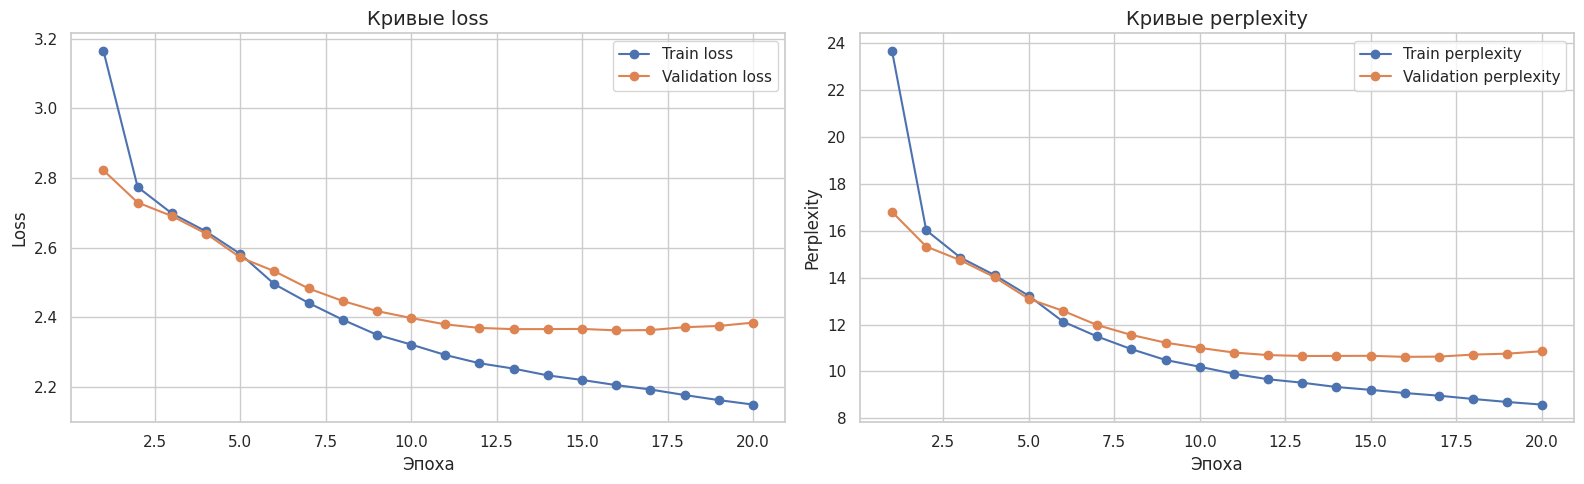

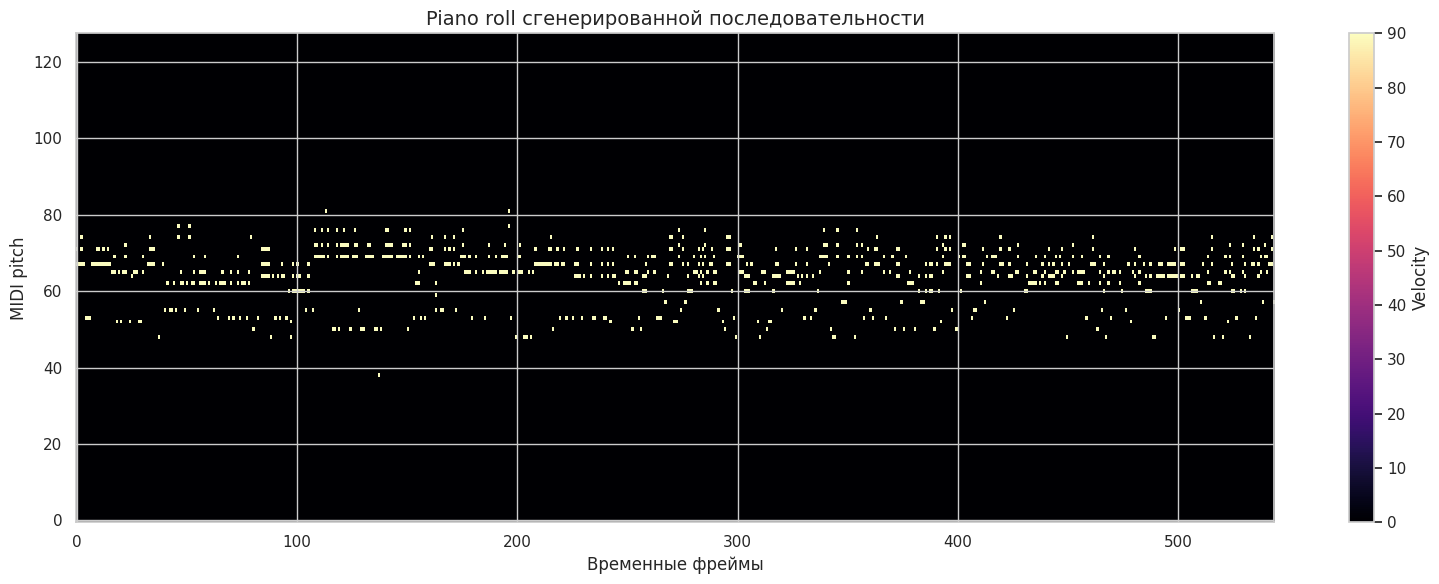

In [20]:
def plot_training_curves(history: dict) -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train loss")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    axes[0].set_title("Кривые loss")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_ppl"], marker="o", label="Train perplexity")
    axes[1].plot(epochs, history["val_ppl"], marker="o", label="Validation perplexity")
    axes[1].set_title("Кривые perplexity")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Perplexity")
    axes[1].legend()

    plt.tight_layout()
    plt.show()



def plot_piano_roll(
    midi_obj: pretty_midi.PrettyMIDI,
    frame_duration: float,
    title: str,
) -> None:
    fs = max(1, int(round(1.0 / frame_duration)))
    piano_roll = midi_obj.get_piano_roll(fs=fs)

    plt.figure(figsize=(16, 6))
    plt.imshow(
        piano_roll,
        aspect="auto",
        origin="lower",
        interpolation="nearest",
        cmap="magma",
    )
    plt.title(title)
    plt.xlabel("Временные фреймы")
    plt.ylabel("MIDI pitch")
    plt.colorbar(label="Velocity")
    plt.tight_layout()
    plt.show()


plot_training_curves(history)
plot_piano_roll(
    midi_obj=generated_midi,
    frame_duration=CFG["frame_duration"],
    title="Piano roll сгенерированной последовательности",
)

# 21. Attention Maps

Визуализируем attention maps для seed-последовательности.

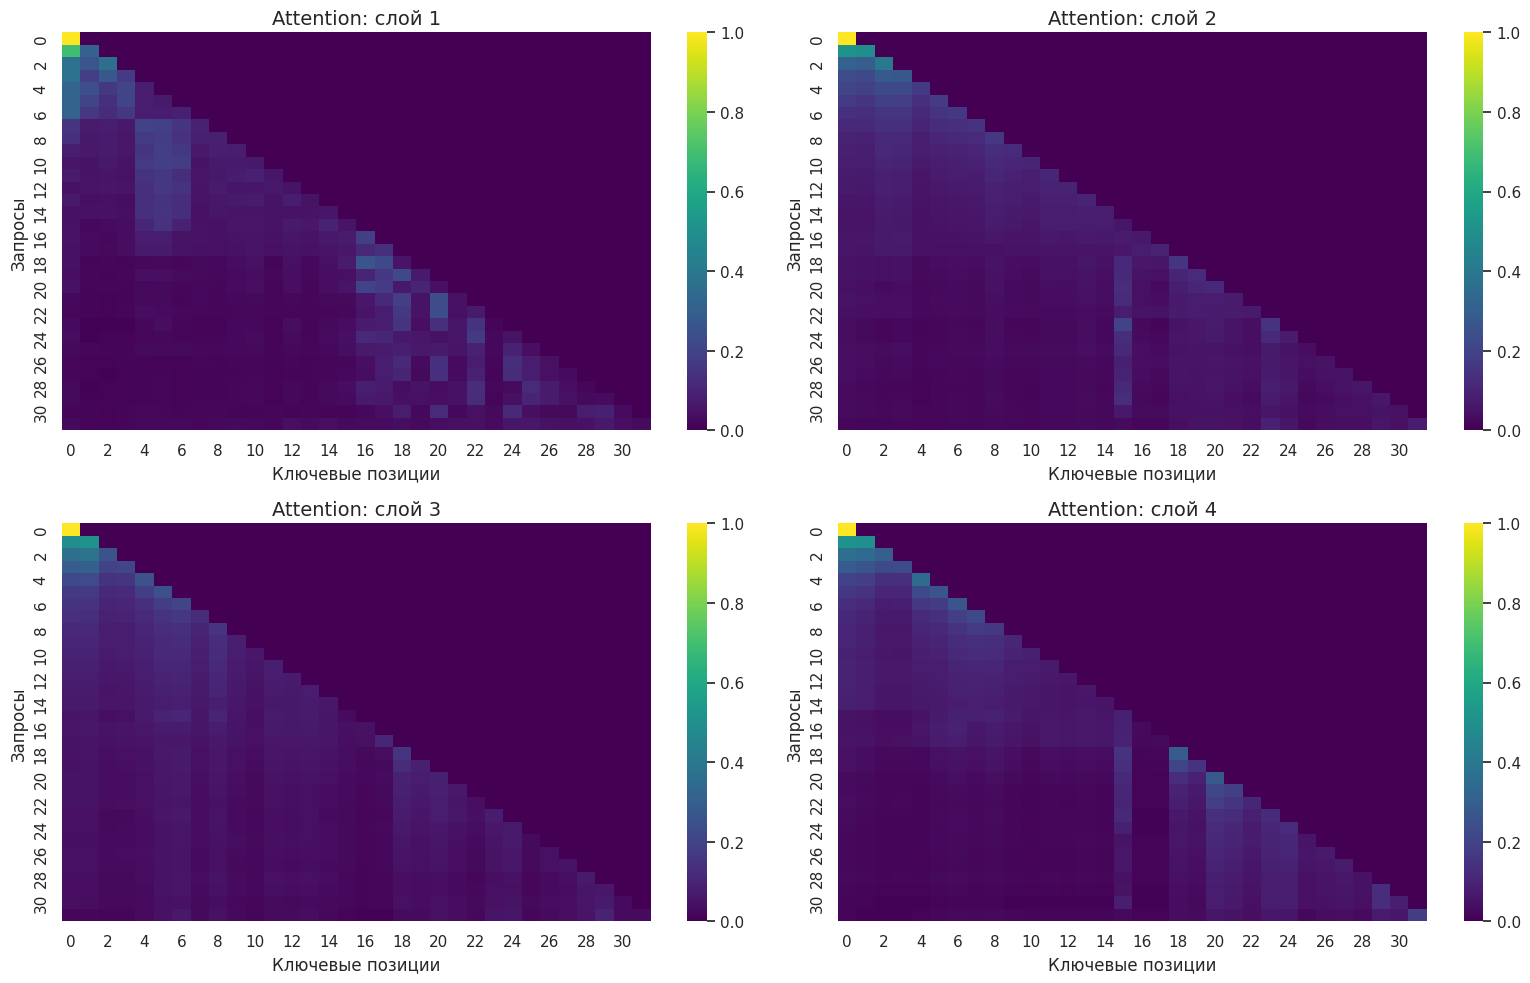

In [21]:
@torch.no_grad()
def get_attention_maps(
    model: nn.Module,
    token_ids: list[int],
    device: torch.device,
    max_tokens: int,
):
    model.eval()
    truncated = token_ids[:max_tokens]
    input_ids = torch.tensor(truncated, dtype=torch.long, device=device).unsqueeze(0)
    _, _, attentions = model(input_ids, return_attentions=True)
    return truncated, attentions



def plot_attention_maps(token_ids: list[int], attentions: list[torch.Tensor], max_tokens: int) -> None:
    if not attentions:
        print("Attention maps не были возвращены моделью.")
        return

    num_layers = len(attentions)
    cols = 2
    rows = math.ceil(num_layers / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for layer_idx, attn_tensor in enumerate(attentions):
        attn_map = attn_tensor[0, :, :max_tokens, :max_tokens].mean(dim=0).numpy()
        sns.heatmap(attn_map, ax=axes[layer_idx], cmap="viridis")
        axes[layer_idx].set_title(f"Attention: слой {layer_idx + 1}")
        axes[layer_idx].set_xlabel("Ключевые позиции")
        axes[layer_idx].set_ylabel("Запросы")

    for axis in axes[num_layers:]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


ATTN_TOKENS, ATTENTIONS = get_attention_maps(
    model=model,
    token_ids=SEED_TOKENS,
    device=device,
    max_tokens=CFG["attention_max_tokens"],
)
plot_attention_maps(
    token_ids=ATTN_TOKENS,
    attentions=ATTENTIONS,
    max_tokens=min(CFG["attention_max_tokens"], len(ATTN_TOKENS)),
)

# 22. Saving Results

Сохраняем артефакты обучения и генерации:

- конфиг;
- history;
- метрики;
- сгенерированные токены;
- отдельный файл с весами модели.

In [22]:
config_path = os.path.join(CFG["artifacts_dir"], "config.json")
history_path = os.path.join(CFG["artifacts_dir"], CFG["history_name"])
metrics_path = os.path.join(CFG["artifacts_dir"], CFG["metrics_name"])
generated_tokens_path = os.path.join(CFG["artifacts_dir"], CFG["generated_tokens_name"])
final_weights_path = os.path.join(CFG["artifacts_dir"], "gpt_frame_level_weights_only.pt")

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(CFG, file, ensure_ascii=False, indent=2)

with open(history_path, "w", encoding="utf-8") as file:
    json.dump(history, file, ensure_ascii=False, indent=2)

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(METRICS, file, ensure_ascii=False, indent=2)

with open(generated_tokens_path, "w", encoding="utf-8") as file:
    json.dump(
        {
            "seed_tokens": SEED_TOKENS,
            "generated_tokens": GENERATED_TOKENS,
        },
        file,
        ensure_ascii=False,
        indent=2,
    )

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": CFG,
    },
    final_weights_path,
)

writer.close()

print("Все основные результаты сохранены.")
print(f"Config: {config_path}")
print(f"History: {history_path}")
print(f"Metrics: {metrics_path}")
print(f"Generated tokens: {generated_tokens_path}")
print(f"Weights only: {final_weights_path}")
print(f"MIDI: {generated_midi_path}")
print(f"TensorBoard logs: {run_dir}")

Все основные результаты сохранены.
Config: /content/drive/MyDrive/midi_gpt_project/artifacts/config.json
History: /content/drive/MyDrive/midi_gpt_project/artifacts/training_history.json
Metrics: /content/drive/MyDrive/midi_gpt_project/artifacts/metrics.json
Generated tokens: /content/drive/MyDrive/midi_gpt_project/artifacts/generated_tokens.json
Weights only: /content/drive/MyDrive/midi_gpt_project/artifacts/gpt_frame_level_weights_only.pt
MIDI: /content/drive/MyDrive/midi_gpt_project/artifacts/generated_sample.mid
TensorBoard logs: /content/drive/MyDrive/midi_gpt_project/runs/midi_gpt_decoder_only_20260527_132906
